In [11]:
# %%
# Cell 1: load data, validate columns, coerce types, train simple linear model
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data_dir = Path('..') / 'data'
candidates = [data_dir / 'clean_listings.parquet', data_dir / 'listings.parquet']
df = None
for p in candidates:
    if p.exists():
        df = pd.read_parquet(p)
        print(f'Loaded data from {p}')
        break
if df is None:
    raise FileNotFoundError(f'No parquet file found in {data_dir}. Tried: {candidates}')

# Requested features and target candidates
requested_X = ['bedrooms', 'beds', 'baths', 'amenities_count', 'photos_count', 'rating_overall']
y_candidates = ['ttm_revenue', 'annual_revenue', 'revenue']
y_col = next((c for c in y_candidates if c in df.columns), None)
if y_col is None:
    raise KeyError(f'No target column found. Tried: {y_candidates}. Available: {list(df.columns)}')

# Build X_cols from requested features; provide a small fallback for common name variants
X_cols = [c for c in requested_X if c in df.columns]
# fallback: if 'baths' requested but missing, try to find any column containing 'bath'
if 'baths' in requested_X and 'baths' not in X_cols:
    bath_col = next((c for c in df.columns if 'bath' in c.lower()), None)
    if bath_col and bath_col not in X_cols:
        X_cols.append(bath_col)
        print(f"Using fallback column '{bath_col}' for requested feature 'baths'")
missing = [c for c in requested_X if c not in X_cols]
if missing:
    print(f'Warning: missing requested features: {missing}. Using available features: {X_cols}')
if not X_cols:
    raise KeyError(f'No requested features found in dataframe. Available columns: {list(df.columns)}')

# Coerce to numeric and drop rows with non-numeric/missing values
df_local = df[X_cols + [y_col]].copy()
for c in X_cols + [y_col]:
    df_local[c] = pd.to_numeric(df_local[c], errors='coerce')
n_before = len(df_local)
df_ml = df_local.dropna()
n_after = len(df_ml)
print(f'Dropped {n_before - n_after} rows with missing/non-numeric values; {n_after} rows remain')
if n_after < 10:
    print('Warning: small sample size after cleaning — some steps may be unstable')

X = df_ml[X_cols]
y = df_ml[y_col]

# Train/test split and fit model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
# Fit model with basic error handling
try:
    model.fit(X_train, y_train)
except Exception as e:
    raise RuntimeError(f'Model training failed: {e}')
print(f"R2 Score: {model.score(X_test, y_test):.4f}")

# Build coefficients dataframe robustly (handle unexpected shapes)
coef = getattr(model, 'coef_', None)
if coef is None:
    print('Model has no attribute coef_')
    coeffs = pd.DataFrame({'Feature': X_cols, 'Impact': [None]*len(X_cols)})
else:
    coef_arr = np.ravel(coef)
    if len(coef_arr) != len(X_cols):
        # try to align by truncating or padding with NaN
        print(f'Warning: coef length ({len(coef_arr)}) does not match number of features ({len(X_cols)}); aligning')
    coef_aligned = list(coef_arr[:len(X_cols)]) + [np.nan] * max(0, len(X_cols) - len(coef_arr))
    coeffs = pd.DataFrame({'Feature': X_cols, 'Impact': coef_aligned})
print(coeffs.sort_values(by='Impact', ascending=False))

Loaded data from ..\data\listings.parquet
Dropped 20794 rows with missing/non-numeric values; 75104 rows remain
R2 Score: 0.2503
          Feature        Impact
4  rating_overall  16884.692397
2           baths   7232.060968
0        bedrooms   3849.798279
1            beds    695.972441
3    photos_count    128.375021


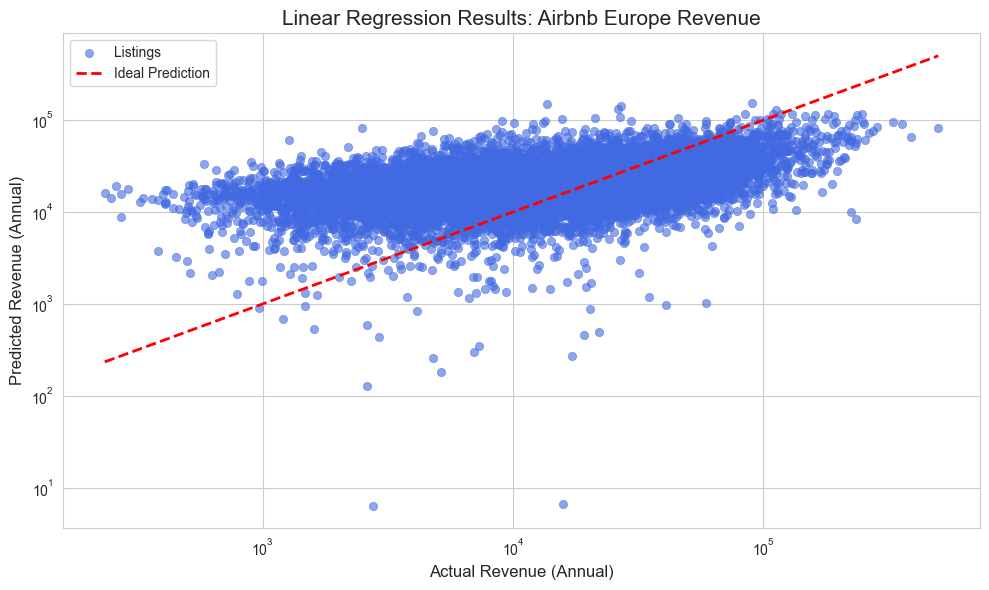

In [12]:
# %%
# Cell 2: plotting actual vs predicted with safe log handling
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions and align with test index
y_pred = model.predict(X_test)
y_test_series = y_test if isinstance(y_test, pd.Series) else pd.Series(y_test, index=X_test.index)
y_pred_series = pd.Series(y_pred, index=y_test_series.index)

# Keep only positive pairs for log scaling
mask = (y_test_series > 0) & (y_pred_series > 0)
if mask.sum() == 0:
    print('No positive Actual/Predicted pairs for log scale; plotting without log scale')
    xs_plot = y_test_series
    ys_plot = y_pred_series
    use_log = False
else:
    xs_plot = y_test_series[mask]
    ys_plot = y_pred_series[mask]
    use_log = True

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
plt.scatter(xs_plot, ys_plot, alpha=0.6, color='royalblue', linewidths=0.5, marker='o', label='Listings')
line_min, line_max = xs_plot.min(), xs_plot.max()
plt.plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--', linewidth=2, label='Ideal Prediction')
if use_log:
    plt.xscale('log')
    plt.yscale('log')
plt.title('Linear Regression Results: Airbnb Europe Revenue', fontsize=15)
plt.xlabel('Actual Revenue (Annual)', fontsize=12)
plt.ylabel('Predicted Revenue (Annual)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

=== FEATURE SET COMPARISON SUMMARY ===
                      Model  Features_Count  Samples_Count  Mean_R2   Std_R2    Mean_RMSE   Std_RMSE
  Full_Model (With Derived)               5          75104 0.249740 0.014261 21987.550659 451.450089
Baseline_Model (No Derived)               3          75104 0.220704 0.015039 22409.222877 474.404171


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18024\1980877566.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='Mean_R2', ax=axes[0], palette='Blues_r')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_18024\1980877566.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='Mean_RMSE', ax=axes[1], palette='Oranges')


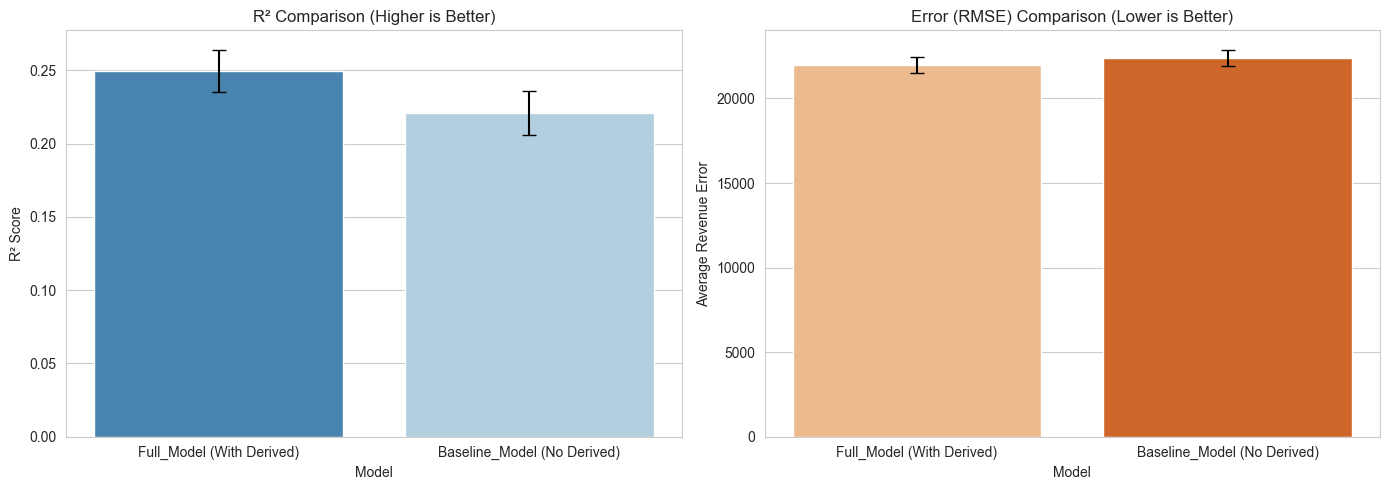

In [13]:
# %%
# Cell 3: cross-validated comparison of feature sets (Optimized & Fair Comparison)
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the two feature subsets based on your actual available columns
feature_sets = {
    'Full_Model (With Derived)': ['bedrooms', 'beds', 'baths', 'photos_count', 'rating_overall'],
    'Baseline_Model (No Derived)': ['bedrooms', 'beds', 'baths']
}

# Native scikit-learn scoring metrics compatible with newer versions
scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}
summary_rows = []
fold_rows = []
max_splits = 5

# CRITICAL: Loop over df_ml to keep the exact same row index space across tests
for set_name, cols in feature_sets.items():
    
    X_local = df_ml[cols]
    y_local = df_ml[y_col]
    
    cv = KFold(n_splits=max_splits, shuffle=True, random_state=42)
    scores = cross_validate(LinearRegression(), X_local, y_local, cv=cv, scoring=scoring, n_jobs=-1)

    # Invert sign of neg_root_mean_squared_error to get positive RMSE values
    rmse_values = -scores['test_rmse']
    r2_values = scores['test_r2']

    for i, (r2_i, rmse_i) in enumerate(zip(r2_values, rmse_values), start=1):
        fold_rows.append({'Model': set_name, 'Fold': i, 'R2': r2_i, 'RMSE': rmse_i})

    summary_rows.append({
        'Model': set_name,
        'Features_Count': len(cols),
        'Samples_Count': len(df_ml),
        'Mean_R2': np.mean(r2_values),
        'Std_R2': np.std(r2_values),
        'Mean_RMSE': np.mean(rmse_values),
        'Std_RMSE': np.std(rmse_values),
    })

fold_df = pd.DataFrame(fold_rows)
comparison_df = pd.DataFrame(summary_rows)

# Print Summary Tables
print('=== FEATURE SET COMPARISON SUMMARY ===')
print(comparison_df.to_string(index=False))

# Generate Performance Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_style('whitegrid')

# R2 Score Plot (Higher is Better)
sns.barplot(data=comparison_df, x='Model', y='Mean_R2', ax=axes[0], palette='Blues_r')
axes[0].errorbar(x=comparison_df['Model'], y=comparison_df['Mean_R2'], yerr=comparison_df['Std_R2'], fmt='none', c='black', capsize=5)
axes[0].set_title('R² Comparison (Higher is Better)', fontsize=12)
axes[0].set_ylabel('R² Score')

# RMSE Plot (Lower is Better - measures error in target currency)
sns.barplot(data=comparison_df, x='Model', y='Mean_RMSE', ax=axes[1], palette='Oranges')
axes[1].errorbar(x=comparison_df['Model'], y=comparison_df['Mean_RMSE'], yerr=comparison_df['Std_RMSE'], fmt='none', c='black', capsize=5)
axes[1].set_title('Error (RMSE) Comparison (Lower is Better)', fontsize=12)
axes[1].set_ylabel('Average Revenue Error')

plt.tight_layout()
plt.show()